<a href="https://colab.research.google.com/github/imalanbrito/DeteccionPlantas/blob/main/Deteccion_V1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
!pip install split-folders pillow ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.7 MB/s eta 0:00:00


In [4]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="0YtqqCozPYWYp4KU99WP")
project = rf.workspace("alanbritos-workspace").project("deteccion-brocoli-yolo")
version = project.version(1)
dataset = version.download("yolov5")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 128.2 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Deteccion-Brocoli-YOLO-1 in yolov5pytorch:: 100%|██████████| 336/336 [00:00<00:00, 6170.07it/s]


In [5]:
file_path = '/content/Deteccion-Brocoli-YOLO-1/data.yaml'

if os.path.exists(file_path):
  print(f"the file at {file_path} exists")
else:
  print(f"the file at {file_path} does not exist")

the file at /content/Deteccion-Brocoli-YOLO-1/data.yaml exists


In [6]:
cwd = os.getcwd()
print(f"Current working directory: {cwd}")

files = os.listdir(cwd)
print(f"file and firectories in '{cwd}': {files}")

Current working directory: /content
file and firectories in '/content': ['.config', 'Deteccion-Brocoli-YOLO-1', 'sample_data']


In [8]:
dir_patch = cwd + "/sample_data"

# Ensure the directory exists before attempting to modify its contents
if os.path.exists(dir_patch) and os.path.isdir(dir_patch):
  for filename in os.listdir(dir_patch):
    file_path_to_remove = os.path.join(dir_patch, filename)
    if os.path.isfile(file_path_to_remove): # Ensure it's a file before removing
      os.remove(file_path_to_remove)
  os.rmdir(dir_patch)
else:
  print(f"Directory {dir_patch} does not exist or is not a directory.")

In [9]:
from ultralytics import YOLO

# Load a COCO-pretrained YOLOv5n model
model = YOLO("yolov5n.pt")

# Display model information (optional)
model.info()


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PRO TIP 💡 Replace 'model=yolov5n.pt' with new 'model=yolov5nu.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.

YOLOv5n summary: 153 layers, 2,654,816 parameters, 0 gradients, 7.8 GFLOPs


(153, 2654816, 0, 7.840102399999999)

In [11]:
from ultralytics import settings

settings.update({'datasets_dir': '/content/Deteccion-Brocoli-YOLO-1'})

In [18]:
import yaml
import os
import splitfolders

data_yaml_path = '/content/Deteccion-Brocoli-YOLO-1/data.yaml'
dataset_root = os.path.dirname(data_yaml_path)

# Define the source directory for images and labels (where Roboflow extracted everything)
source_data_dir = os.path.join(dataset_root, 'train') # Assuming Roboflow dumped everything into 'train'
output_split_dir = os.path.join(dataset_root, 'split_data') # New directory for split data

# Check if the source directory exists and contains data
if os.path.exists(source_data_dir) and len(os.listdir(source_data_dir)) > 0:
    print(f"Splitting data from {source_data_dir}...")
    # Split data into train, val, test with a ratio
    # ratio=(train, val, test) - here 70% train, 20% val, 10% test
    splitfolders.ratio(source_data_dir, output=output_split_dir, seed=42, ratio=(0.7, 0.2, 0.1), group_prefix=None)
    print(f"Data split into {output_split_dir}/train, {output_split_dir}/val, {output_split_dir}/test")

    # Update data.yaml to point to the new split directories
    with open(data_yaml_path, 'r') as f:
        data_yaml_content = yaml.safe_load(f)

    if 'path' in data_yaml_content:
        del data_yaml_content['path']

    data_yaml_content['train'] = os.path.join(output_split_dir, 'train', 'images')
    data_yaml_content['val'] = os.path.join(output_split_dir, 'val', 'images')
    data_yaml_content['test'] = os.path.join(output_split_dir, 'test', 'images')

    # Roboflow export often has labels directly in the image folders, or in a separate 'labels' folder.
    # Assuming the splitfolders library creates 'images' and 'labels' subfolders within each split (train, val, test).
    # If splitfolders doesn't create 'images' and 'labels' automatically, you might need to adjust this part.
    # For YOLO, it's common to have labels in the same directory as images or in a parallel 'labels' directory.
    # The below assumes structure after split: split_data/train/images, split_data/train/labels etc.
    # We also need to ensure the labels for these images are correctly placed.
    # Roboflow usually provides them directly.

    with open(data_yaml_path, 'w') as f:
        yaml.dump(data_yaml_content, f)
    print("data.yaml updated with new split paths.")

else:
    print(f"Source data directory {source_data_dir} is empty or does not exist. Please check your Roboflow extraction.")

# Proceed with model training
model.train(
    data=data_yaml_path, # Use the path to the modified data.yaml
    epochs=100,
    imgsz=640,
    batch=16,
    name="entrenamiento_brocoli",
    project="proyecto_brocoli"
)

Splitting data from /content/Deteccion-Brocoli-YOLO-1/train...


Copying files: 330 files [00:00, 6182.09 files/s]

Data split into /content/Deteccion-Brocoli-YOLO-1/split_data/train, /content/Deteccion-Brocoli-YOLO-1/split_data/val, /content/Deteccion-Brocoli-YOLO-1/split_data/test
data.yaml updated with new split paths.
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Deteccion-Brocoli-YOLO-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_rati

YOLOv5n summary: 154 layers, 2,509,049 parameters, 2,509,033 gradients, 7.2 GFLOPs

Transferred 427/427 items from pretrained weights
Freezing layer 'model.24.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...
AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 745.5±196.9 MB/s, size: 30.1 KB)
train: Scanning /content/Deteccion-Brocoli-YOLO-1/split_data/train/labels... 115 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 115/115 1.8Kit/s 0.1s
train: New cache created: /content/Deteccion-Brocoli-YOLO-1/split_data/train/labels.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 406.2±194.9 MB/s, size: 33.5 KB)
val: Scanning /content/Deteccion-Brocoli-YOLO-1/split_data/val/labels... 33 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7bfb9a0f12b0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [20]:
import os
directory = "/content/runs/detect/proyecto_brocoli/entrenamiento_brocoli6"
if os.path.exists(directory):
  print("archivos en el directorio:")
  print(os.listdir(directory))
else:
  print(f"El directorio {directory} no existe")

archivos en el directorio:
['results.png', 'BoxPR_curve.png', 'val_batch0_labels.jpg', 'train_batch720.jpg', 'train_batch721.jpg', 'train_batch1.jpg', 'train_batch2.jpg', 'confusion_matrix_normalized.png', 'results.csv', 'labels.jpg', 'train_batch722.jpg', 'val_batch1_labels.jpg', 'BoxP_curve.png', 'train_batch0.jpg', 'val_batch1_pred.jpg', 'val_batch0_pred.jpg', 'weights', 'BoxR_curve.png', 'args.yaml', 'confusion_matrix.png', 'BoxF1_curve.png']


In [21]:
df_metrics = pd.read_csv("/content/runs/detect/proyecto_brocoli/entrenamiento_brocoli6/results.csv")

print(df_metrics.head(5))

print(df_metrics.index.to_list())
print(df_metrics.columns.to_list())

df_metrics.describe()

   epoch      time  train/box_loss  train/cls_loss  train/dfl_loss  \
0      1   6.41566         1.33969         3.30729         1.71901   
1      2   8.95593         1.13641         3.13156         1.60429   
2      3  11.34520         1.01753         2.81857         1.50298   
3      4  13.77670         1.02286         2.52528         1.48162   
4      5  16.77060         0.93717         2.31228         1.43021   

   metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
0               0.00372            0.96491           0.12358   
1               0.00419            0.96491           0.28084   
2               0.00383            0.91404           0.19015   
3               0.00412            0.98246           0.17984   
4               0.00414            0.96491           0.32451   

   metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/dfl_loss    lr/pg0  \
0              0.05983       1.32118       3.18238       2.03836  0.000100   
1              0.13590       1.25334  

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,50.500000,134.003169,0.740651,1.205066,1.250320,0.784911,0.842309,0.822780,0.614576,0.993535,1.249092,1.530546,0.000648,0.000648,0.000648
std,29.011492,75.239292,0.190354,0.546247,0.142652,0.269695,0.202340,0.253405,0.259706,0.487701,0.750175,0.556307,0.000360,0.000360,0.000360
min,1.000000,6.415660,0.412980,0.628260,1.054520,0.003720,0.172650,0.123580,0.059830,0.490610,0.541830,0.921090,0.000028,0.000028,0.000028
25%,25.750000,69.824100,0.571895,0.787155,1.129910,0.719328,0.791392,0.760290,0.433762,0.581527,0.645465,1.068793,0.000336,0.000336,0.000336
50%,50.500000,133.272000,0.724540,1.039685,1.214450,0.916275,0.941170,0.970645,0.709455,0.833360,0.919510,1.374045,0.000645,0.000645,0.000645
75%,75.250000,197.778750,0.887390,1.409550,1.349317,0.963230,0.982832,0.993350,0.833070,1.322460,1.704282,1.921617,0.000952,0.000952,0.000952
max,100.000000,263.185000,1.339690,3.307290,1.719010,0.994970,1.000000,0.995000,0.887230,2.858020,3.182380,3.513270,0.001259,0.001259,0.001259


['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


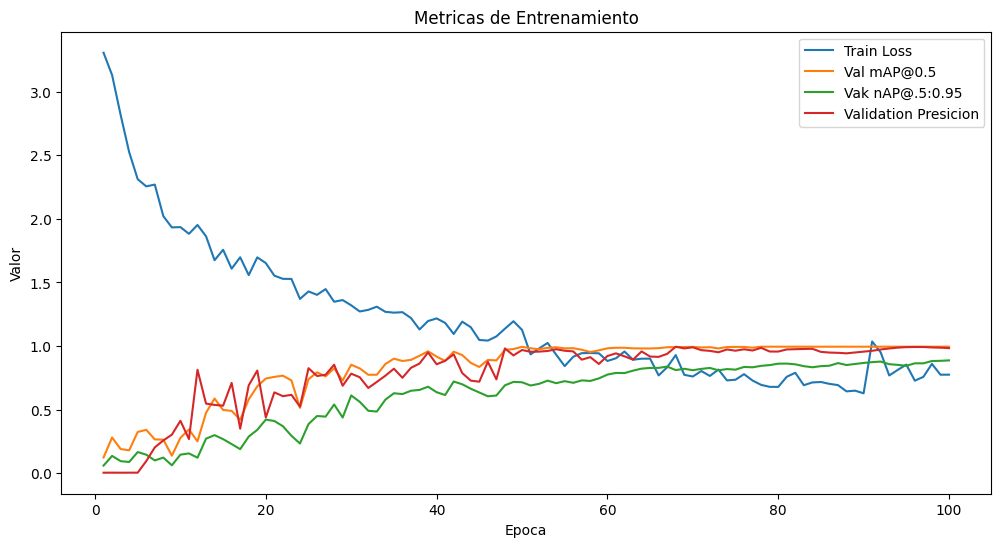

In [23]:
print(df_metrics.columns.to_list())

plt.figure(figsize=(12,6))
plt.plot(df_metrics[['epoch']], df_metrics[['train/cls_loss']], label='Train Loss')
plt.plot(df_metrics[['epoch']], df_metrics[['metrics/mAP50(B)']], label='Val mAP@0.5')
plt.plot(df_metrics[['epoch']], df_metrics[['metrics/mAP50-95(B)']], label='Vak nAP@.5:0.95')
plt.plot(df_metrics[['epoch']], df_metrics[['metrics/precision(B)']], label='Validation Presicion')
plt.xlabel('Epoca')
plt.ylabel('Valor')
plt.title('Metricas de Entrenamiento')
plt.legend()
plt.show()

In [24]:
results = model.val()

print(results)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv5n summary (fused): 85 layers, 2,503,529 parameters, 0 gradients, 7.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1309.8±292.5 MB/s, size: 32.1 KB)
val: Scanning /content/Deteccion-Brocoli-YOLO-1/split_data/val/labels.cache... 33 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 33/33 13.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 2.6it/s 1.1s
                   all         33         37      0.984      0.986      0.995      0.887
       Brocoli Enfermo          8          8      0.976          1      0.995      0.919
               brocoli         16         19          1      0.958      0.995      0.932
                maleza          9         10      0.975          1      0.995      0.811
Speed: 6.4ms preprocess, 10.3ms inference, 0.0ms loss, 3.1ms postprocess per image
Results saved to /content/runs/d

In [26]:
#Cargar el modelo entrenado
modelo_entrenado = YOLO("/content/runs/detect/proyecto_brocoli/entrenamiento_brocoli6/weights/best.pt")

#Realizar inferencia en una imagen
resultados = modelo_entrenado.predict(source="/content/brocoli.jpg", save=True)

#acceder a los resultados
for resultado in resultados:
  print(f"Predicciones para la imagen: {resultado.path}")

  for caja, conf, clase in zip(resultado.boxes.xyxy, resultado.boxes.conf, resultado.boxes.cls):
    print(f"Bounding Box: {caja}, Confianza: {conf}, Clase: {int(clase)}")


image 1/1 /content/brocoli.jpg: 448x640 1 Brocoli Enfermo, 1 brocoli, 16.1ms
Speed: 3.6ms preprocess, 16.1ms inference, 1.8ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict2
Predicciones para la imagen: /content/brocoli.jpg
Bounding Box: tensor([ 303.3914,   20.6651, 1121.8486,  808.7228], device='cuda:0'), Confianza: 0.9132135510444641, Clase: 1
Bounding Box: tensor([ 316.5126,   22.1014, 1137.2017,  797.4271], device='cuda:0'), Confianza: 0.3069620430469513, Clase: 0


### Using Webcam for Instant Feedback

Since Colab runs in the cloud, direct real-time webcam access for continuous video stream processing is challenging. However, you can capture a single frame from your webcam in your browser, send it to the Colab runtime, and then perform inference on that captured image using your trained model.

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture Photo';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture to be clicked.
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename

try:
  filename = take_photo()
  print('Saved to {}'.format(filename))

  # Perform inference on the captured image
  print(f"Performing inference on {filename}...")
  resultados_webcam = modelo_entrenado.predict(source=filename, save=True, project="proyecto_brocoli_webcam_predict")

  # Display results
  for resultado in resultados_webcam:
    print(f"Predicciones para la imagen: {resultado.path}")
    for caja, conf, clase in zip(resultado.boxes.xyxy, resultado.boxes.conf, resultado.boxes.cls):
      print(f"Bounding Box: {caja}, Confianza: {conf}, Clase: {int(clase)}")

  # Load and display the image with predictions
  prediction_image_path = os.path.join("/content/runs/detect/proyecto_brocoli_webcam_predict", os.path.basename(filename))
  img_webcam = Image.open(prediction_image_path)
  plt.imshow(img_webcam)
  plt.axis("off")
  plt.title("Webcam Image with Predictions")
  plt.show()

except Exception as err:
  # Errors will be thrown if the user does not have a webcam or does not allow access
  print(str(err))


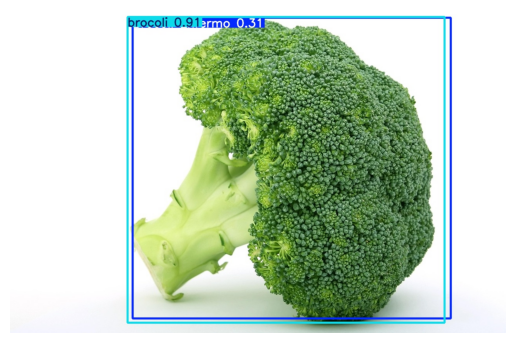

In [30]:
# cargar y mostrar la imagen con las predicciones
img = Image.open("/content/runs/detect/predict/brocoli.jpg")
plt.imshow(img)
plt.axis("off")
plt.show()